# Big Five Personality Test — SVM Model Training

**ที่มาของข้อมูล:** Big Five Personality Test (2016–2018) จาก IPIP  
**เป้าหมาย:** ทำนายพฤติกรรมเฉพาะตัว 7 ประการ จากคะแนนบุคลิกภาพ 43 ข้อที่เหลือ

---

### พฤติกรรม 7 ประการที่เป็น Target (drop ออกจาก features):
| Column | คำถาม | ด้าน |
|--------|--------|------|
| CSN6 | I often forget to put things back in their proper place. | Conscientiousness |
| AGR9 | I feel others' emotions. | Agreeableness |
| AGR5 | I am not interested in other people's problems. | Agreeableness |
| EXT4 | I keep in the background. | Extraversion |
| EST7 | I change my mood a lot. | Neuroticism |
| OPN3 | I have a vivid imagination. | Openness |
| OPN10 | I am full of ideas. | Openness |

# 0 — Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
import joblib, os, warnings

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print('Libraries loaded successfully.')

Libraries loaded successfully.


# 1 — Load Data

In [3]:
df_raw = pd.read_csv('data-final.csv', sep='\t')
print(f'Raw data shape: {df_raw.shape}')
df_raw.head(3)

Raw data shape: (1015341, 110)


,EXT1,EXT2,EXT3,EXT4,EXT5,EXT6,EXT7,EXT8,EXT9,EXT10,...,dateload,screenw,screenh,introelapse,testelapse,endelapse,IPC,country,lat_appx_lots_of_err,long_appx_lots_of_err
0,4.0,1.0,5.0,2.0,5.0,1.0,5.0,2.0,4.0,1.0,...,2016-03-03 02:01:01,768.0,1024.0,9.0,234.0,6,1,GB,51.5448,0.1991
1,3.0,5.0,3.0,4.0,3.0,3.0,2.0,5.0,1.0,5.0,...,2016-03-03 02:01:20,1360.0,768.0,12.0,179.0,11,1,MY,3.1698,101.706
2,2.0,3.0,4.0,4.0,3.0,2.0,1.0,3.0,2.0,5.0,...,2016-03-03 02:01:56,1366.0,768.0,3.0,186.0,7,1,GB,54.9119,-1.3833


# 2 — Data Cleaning & Preparation

In [4]:
# 2.1 เลือก 50 columns
EXT_cols = [f'EXT{i}' for i in range(1, 11)]
EST_cols = [f'EST{i}' for i in range(1, 11)]
AGR_cols = [f'AGR{i}' for i in range(1, 11)]
CSN_cols = [f'CSN{i}' for i in range(1, 11)]
OPN_cols = [f'OPN{i}' for i in range(1, 11)]

all_question_cols = EXT_cols + EST_cols + AGR_cols + CSN_cols + OPN_cols
df = df_raw[all_question_cols].copy()
print(f'Selected data shape: {df.shape}')

Selected data shape: (1015341, 50)


In [5]:
# 2.2 Missing Values
df = df.dropna()
print(f'Shape after dropna: {df.shape}')

Shape after dropna: (1013558, 50)


In [6]:
# 2.3 Outlier Removal
mask_valid = (df >= 1).all(axis=1) & (df <= 5).all(axis=1)
df = df[mask_valid].copy().astype(int)
print(f'Shape after outlier removal: {df.shape}')

Shape after outlier removal: (874434, 50)


In [7]:
# 2.4 Reverse Scoring
reverse_cols = [
    'EXT2','EXT4','EXT6','EXT8','EXT10',
    'EST2','EST4',
    'AGR1','AGR3','AGR5','AGR7',
    'CSN2','CSN4','CSN6','CSN8',
    'OPN2','OPN4','OPN6'
]

df_transformed = df.copy()
df_transformed[reverse_cols] = 6 - df_transformed[reverse_cols]
print(f'Reverse-scored: {len(reverse_cols)} columns')

Reverse-scored: 18 columns


In [8]:
# 2.5 Trait Mean Scores
df_transformed['EXT_score'] = df_transformed[EXT_cols].mean(axis=1)
df_transformed['EST_score'] = df_transformed[EST_cols].mean(axis=1)
df_transformed['AGR_score'] = df_transformed[AGR_cols].mean(axis=1)
df_transformed['CSN_score'] = df_transformed[CSN_cols].mean(axis=1)
df_transformed['OPN_score'] = df_transformed[OPN_cols].mean(axis=1)

df_transformed[['EXT_score','EST_score','AGR_score','CSN_score','OPN_score']].describe().round(3)

,EXT_score,EST_score,AGR_score,CSN_score,OPN_score
count,874434.000,874434.000,874434.000,874434.000,874434.000
mean,2.959,3.067,3.774,3.366,3.899
std,0.910,0.859,0.729,0.737,0.630
min,1.000,1.000,1.000,1.000,1.000
25%,2.300,2.400,3.300,2.900,3.500
50%,3.000,3.100,3.900,3.400,3.900
75%,3.600,3.700,4.300,3.900,4.400
max,5.000,5.000,5.000,5.000,5.000


In [9]:
# 2.6 Features & Targets
TARGET_COLS = ['CSN6','AGR9','AGR5','EXT4','EST7','OPN3','OPN10']
TARGET_LABELS = {
    'CSN6':  'ลืมวางของ (CSN6)',
    'AGR9':  'รู้สึกอารมณ์คนอื่น (AGR9)',
    'AGR5':  'สนใจปัญหาคนอื่น (AGR5)',
    'EXT4':  'ชอบอยู่ในพื้นหลัง (EXT4)',
    'EST7':  'อารมณ์แปรปรวน (EST7)',
    'OPN3':  'จินตนาการสูง (OPN3)',
    'OPN10': 'มีไอเดียมาก (OPN10)'
}

FEATURE_COLS = [c for c in all_question_cols if c not in TARGET_COLS]
X = df_transformed[FEATURE_COLS].copy()
y = df_transformed[TARGET_COLS].copy()

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

X shape: (874434, 43)
y shape: (874434, 7)


# 3 — EDA

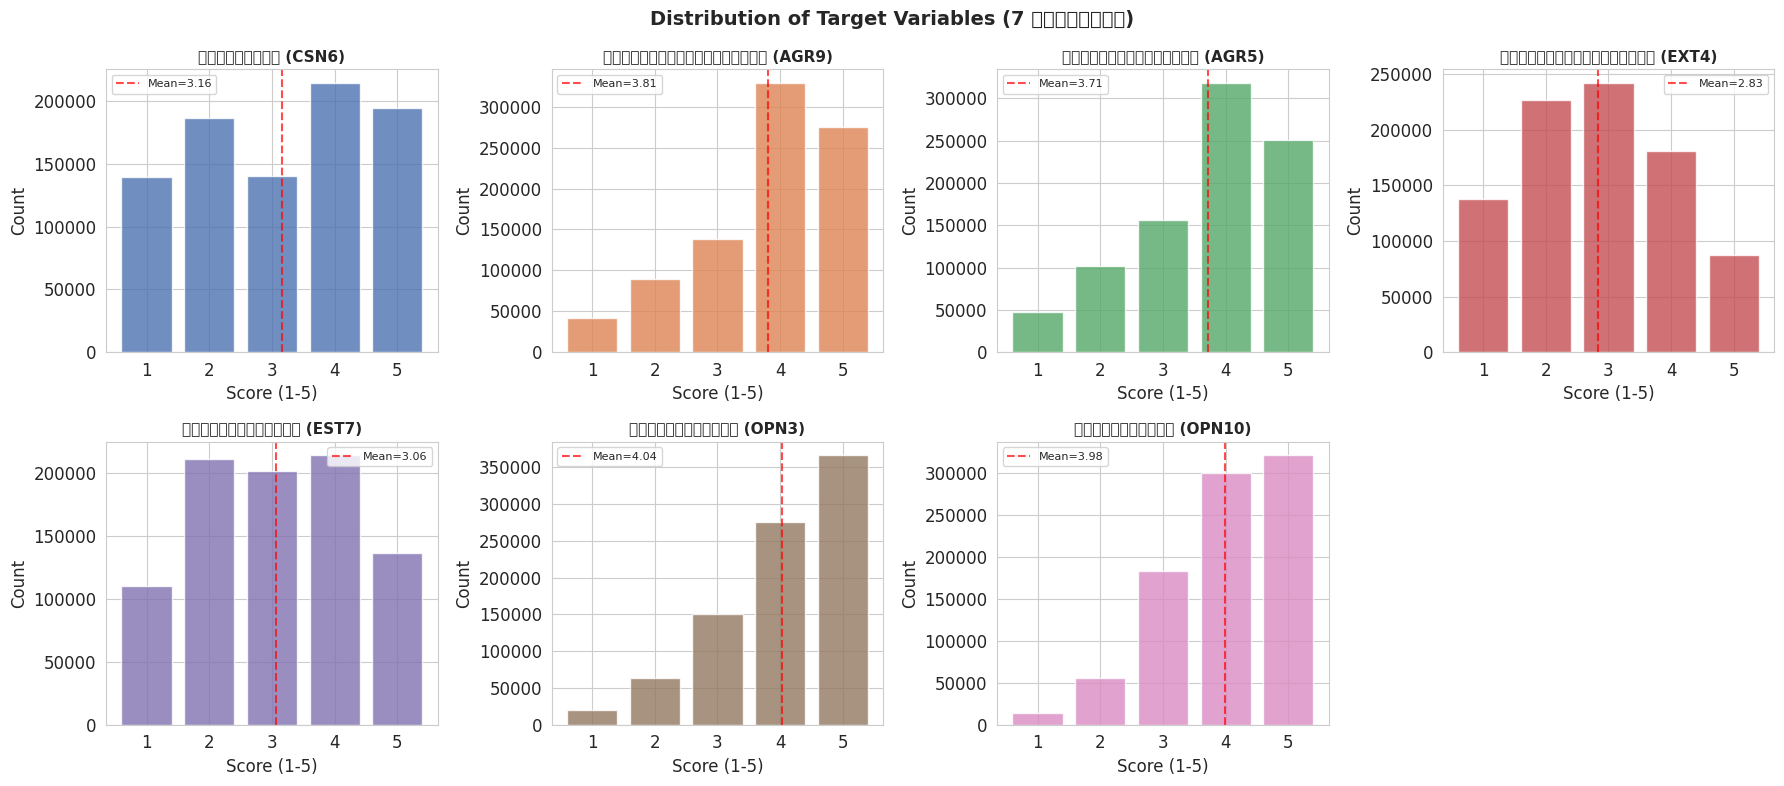

In [10]:
# 3.1 Distribution ของ Target Variables
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
colors = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#937860','#DA8BC3']

for i, col in enumerate(TARGET_COLS):
    ax = axes[i]
    vc = y[col].value_counts().sort_index()
    ax.bar(vc.index, vc.values, color=colors[i], alpha=0.8, edgecolor='white')
    ax.set_title(TARGET_LABELS[col], fontsize=11, fontweight='bold')
    ax.set_xlabel('Score (1-5)')
    ax.set_ylabel('Count')
    ax.set_xticks([1,2,3,4,5])
    mean_val = y[col].mean()
    ax.axvline(mean_val, color='red', linestyle='--', alpha=0.7, label=f'Mean={mean_val:.2f}')
    ax.legend(fontsize=8)

axes[-1].set_visible(False)
fig.suptitle('Distribution of Target Variables (7 พฤติกรรม)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

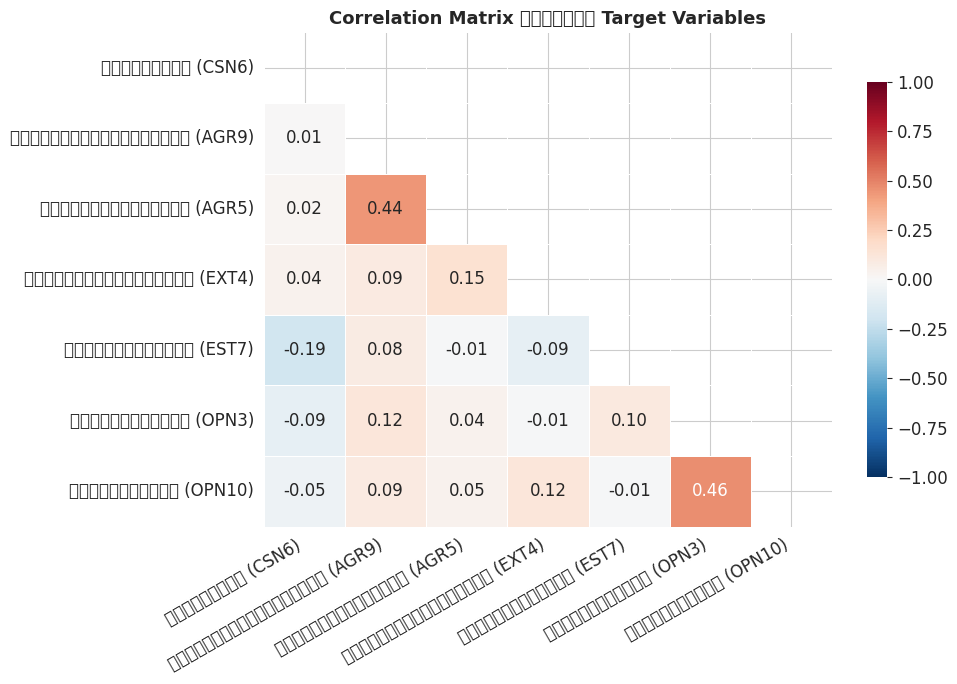

In [11]:
# 3.2 Correlation ระหว่าง Targets
target_corr = y.corr()
target_corr.index   = [TARGET_LABELS[c] for c in TARGET_COLS]
target_corr.columns = [TARGET_LABELS[c] for c in TARGET_COLS]

plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(target_corr, dtype=bool))
sns.heatmap(target_corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix ระหว่าง Target Variables', fontsize=13, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

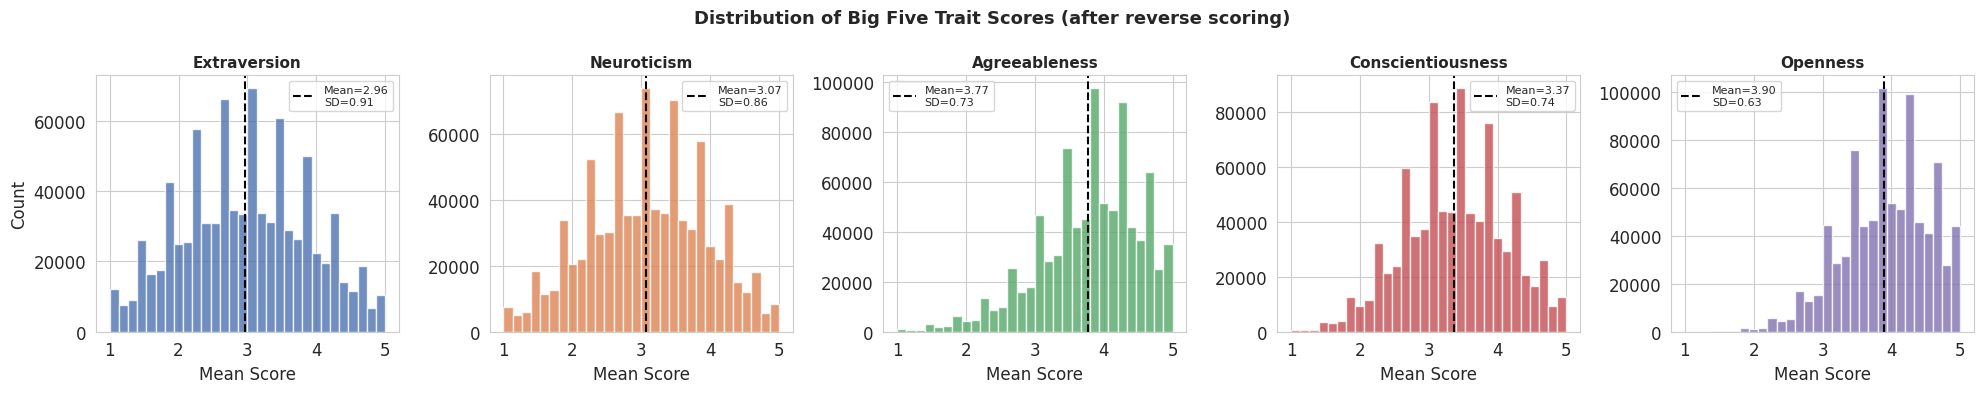

In [12]:
# 3.3 Distribution Big Five Trait Scores
trait_info = {
    'EXT_score': ('Extraversion',      '#4C72B0'),
    'EST_score': ('Neuroticism',       '#DD8452'),
    'AGR_score': ('Agreeableness',     '#55A868'),
    'CSN_score': ('Conscientiousness', '#C44E52'),
    'OPN_score': ('Openness',          '#8172B2'),
}

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, (col, (label, color)) in enumerate(trait_info.items()):
    ax = axes[i]
    data = df_transformed[col]
    ax.hist(data, bins=30, color=color, alpha=0.8, edgecolor='white')
    ax.axvline(data.mean(), color='black', linestyle='--', linewidth=1.5,
               label=f'Mean={data.mean():.2f}\nSD={data.std():.2f}')
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xlabel('Mean Score')
    ax.set_ylabel('Count' if i == 0 else '')
    ax.legend(fontsize=8)

fig.suptitle('Distribution of Big Five Trait Scores (after reverse scoring)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

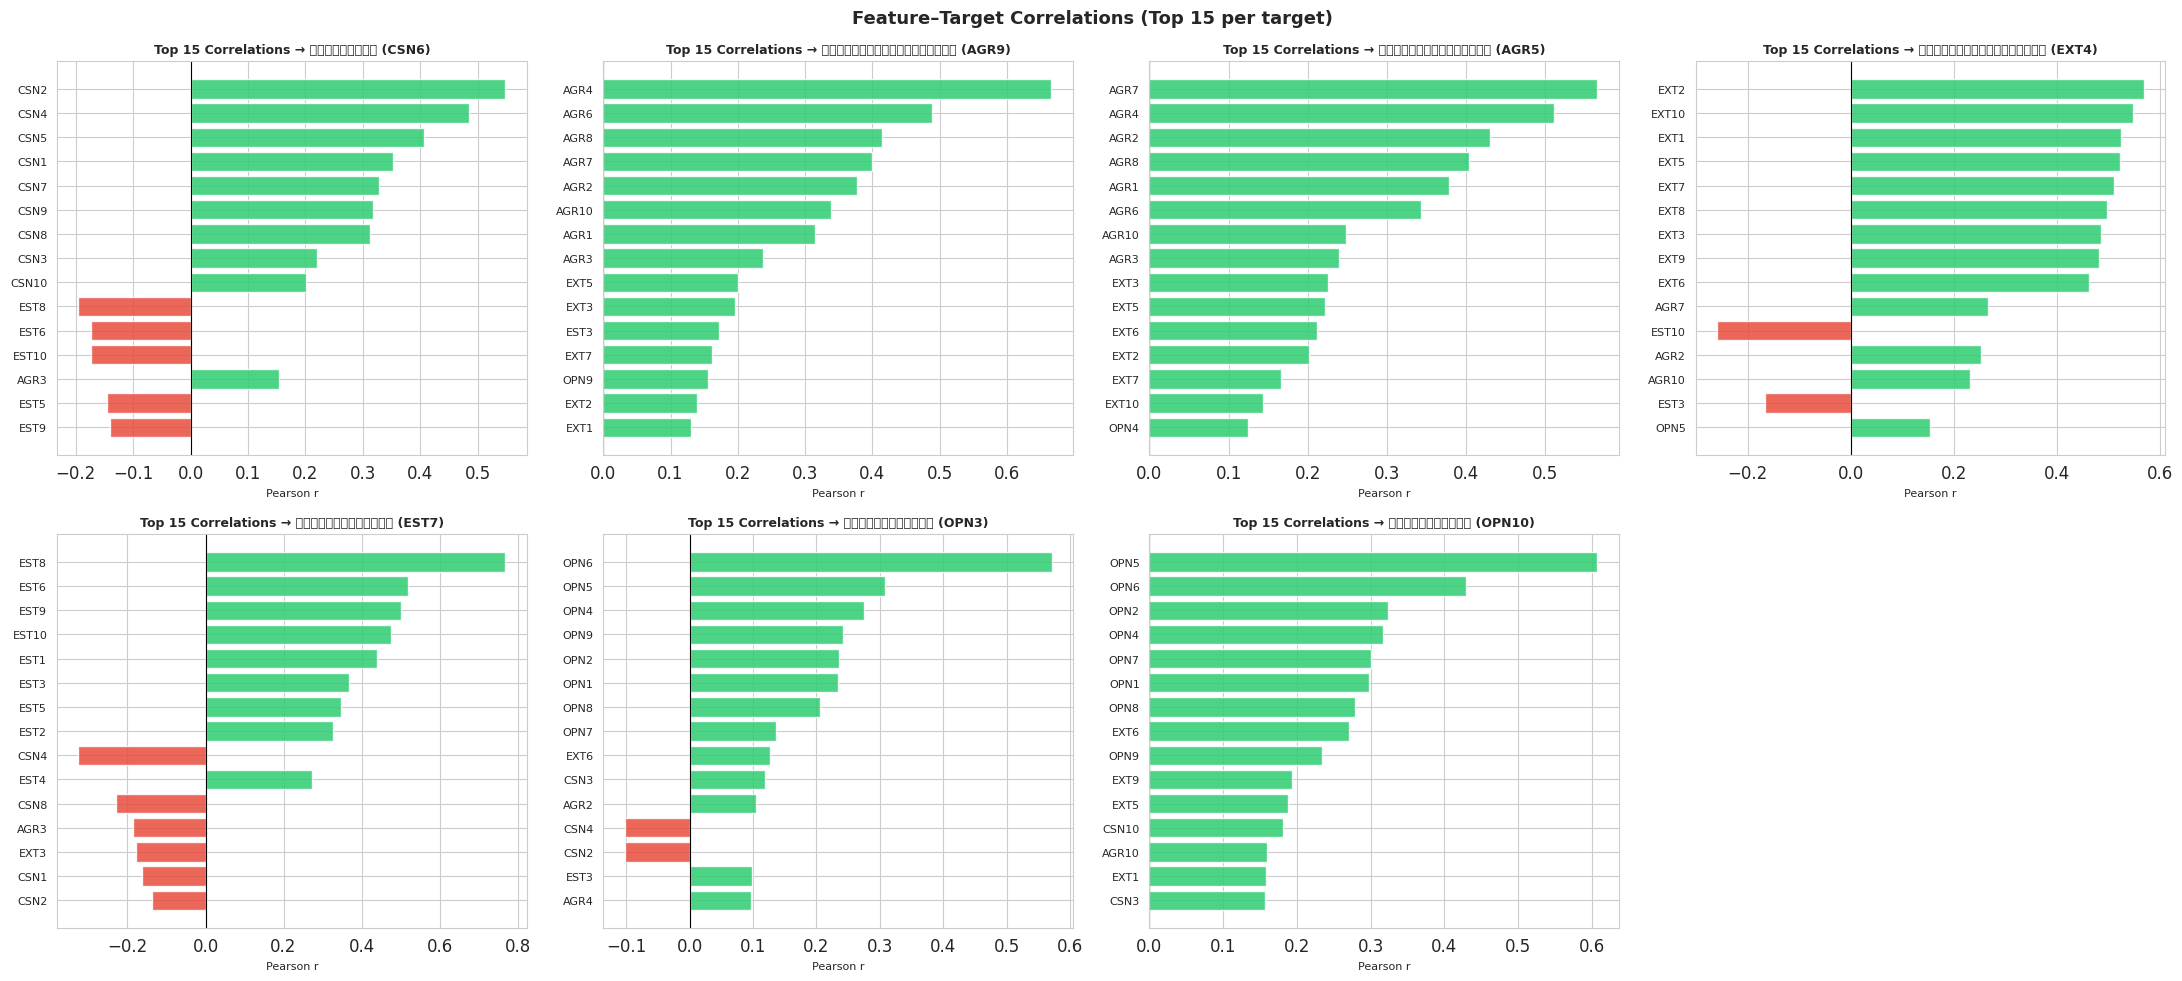

In [13]:
# 3.4 Feature–Target Correlations Top 15
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for i, target in enumerate(TARGET_COLS):
    corr_vals = X.corrwith(y[target]).sort_values(key=abs, ascending=False).head(15)
    ax = axes[i]
    bar_colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in corr_vals.values]
    ax.barh(corr_vals.index[::-1], corr_vals.values[::-1], color=bar_colors[::-1], alpha=0.85)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'Top 15 Correlations → {TARGET_LABELS[target]}', fontsize=9, fontweight='bold')
    ax.set_xlabel('Pearson r', fontsize=8)
    ax.tick_params(axis='y', labelsize=8)

axes[-1].set_visible(False)
fig.suptitle('Feature–Target Correlations (Top 15 per target)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

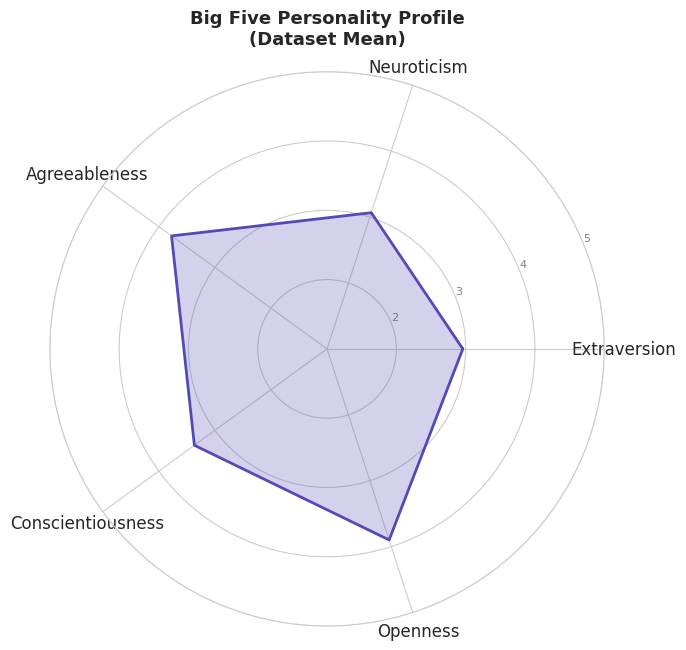

In [14]:
# 3.5 [เพิ่ม] Radar Chart — Big Five Profile ของกลุ่มตัวอย่าง
# Radar chart แสดง Big Five mean score ของทั้ง dataset
trait_means = {
    'Extraversion':      df_transformed['EXT_score'].mean(),
    'Neuroticism':       df_transformed['EST_score'].mean(),
    'Agreeableness':     df_transformed['AGR_score'].mean(),
    'Conscientiousness': df_transformed['CSN_score'].mean(),
    'Openness':          df_transformed['OPN_score'].mean(),
}

labels = list(trait_means.keys())
values = list(trait_means.values())
values += values[:1]  # ปิดวงกลม

angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.plot(angles, values, color='#534AB7', linewidth=2)
ax.fill(angles, values, color='#534AB7', alpha=0.25)
ax.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=12)
ax.set_ylim(1, 5)
ax.set_yticks([2, 3, 4, 5])
ax.set_yticklabels(['2','3','4','5'], fontsize=8, color='gray')
ax.set_title('Big Five Personality Profile\n(Dataset Mean)', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

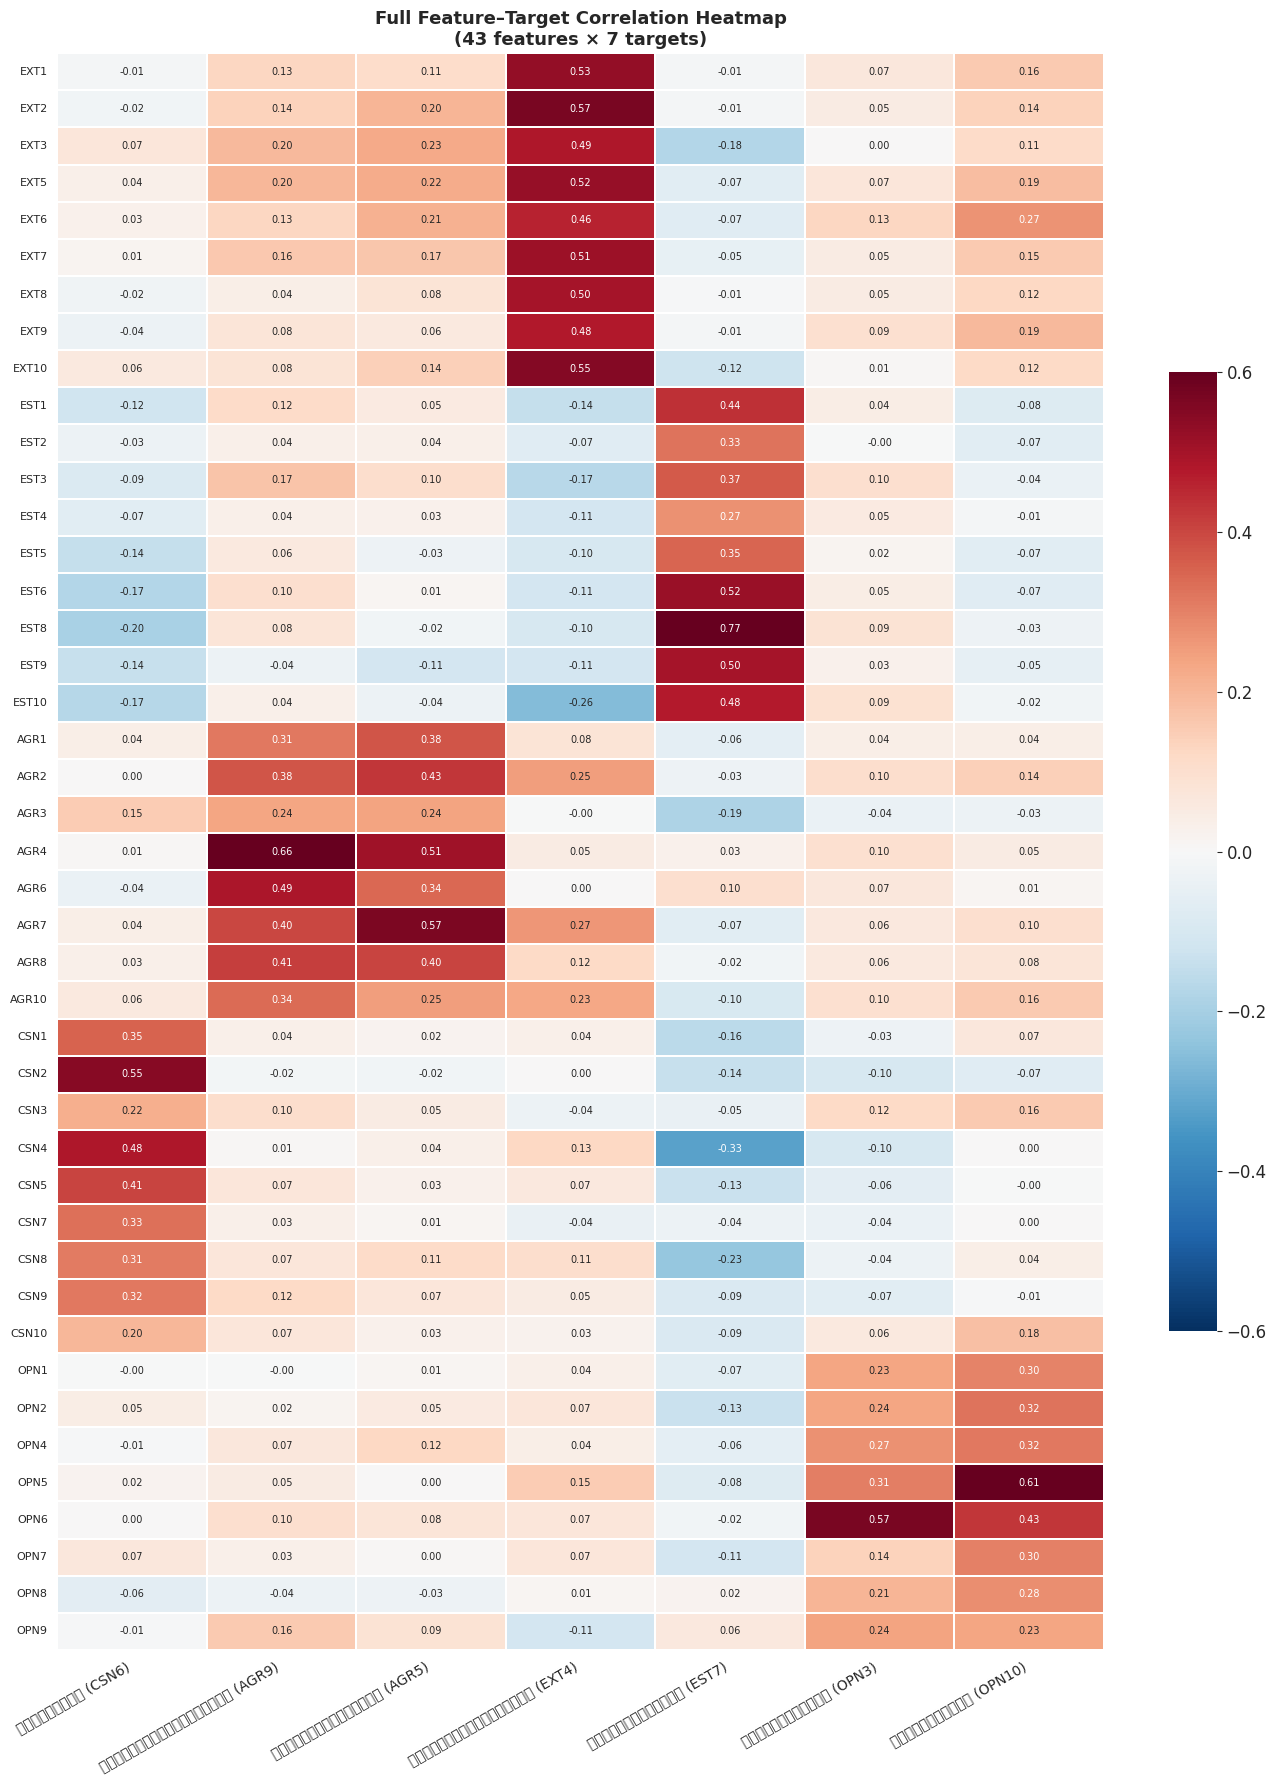

In [15]:
# 3.6 Full Feature–Target Heatmap (43 features × 7 targets)
# Heatmap แบบ full matrix — เห็นภาพรวมว่า feature ไหนสัมพันธ์กับ target ไหน
corr_matrix = pd.DataFrame(
    {t: X.corrwith(y[t]) for t in TARGET_COLS},
    index=FEATURE_COLS
)
corr_matrix.columns = [TARGET_LABELS[c] for c in TARGET_COLS]

plt.figure(figsize=(14, 18))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-0.6, vmax=0.6,
            linewidths=0.3, cbar_kws={'shrink': 0.6},
            annot_kws={'size': 7})
plt.title('Full Feature–Target Correlation Heatmap\n(43 features × 7 targets)',
          fontsize=13, fontweight='bold')
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

# 4 — Train-Test Split + Scale

In [ ]:
# SVM ต้องการ StandardScaler เพราะ sensitive กับ scale ของข้อมูลมาก
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# StandardScaler: ปรับให้ทุก feature มี mean=0, std=1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Train: {X_train_scaled.shape}  |  Test: {X_test_scaled.shape}')

Train: (699547, 43)  |  Test: (174887, 43)


ต่างจาก XGBoost ตรงนี้ — SVM ต้องใช้ StandardScaler เพราะใช้ distance/margin ในการหา hyperplane ถ้าไม่ scale ค่า feature ที่มี range ต่างกันจะทำให้โมเดล bias

# 5 — Train SVM (7 โมเดล)

dataset มี 1 ล้าน row ทำให้ SVM ธรรมดา (kernel='rbf') ใช้เวลานานมาก เราใช้ kernel='rbf' กับ sample 50,000 row เพื่อให้เทรนได้จริง แล้ว note ไว้ใน report

In [ ]:
# ── Sample เพื่อความเร็ว (SVM ไม่ scale ได้ดีกับ 1M rows) ──────────
SAMPLE_SIZE = 50_000
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(X_train_scaled), size=SAMPLE_SIZE, replace=False)

X_tr_sample = X_train_scaled[sample_idx]
y_tr_sample = y_train.iloc[sample_idx]

print(f'Training on {SAMPLE_SIZE:,} samples (sampled from {len(X_train):,})')

# ── SVM Hyperparameters ──────────────────────────────────────────
SVM_PARAMS = dict(
    kernel='rbf',
    C=1.0,         # สูง overfit, ต่ำ underfit
    epsilon=0.3,   # ± margin ที่ยอมรับได้ (scale 1–5 → 0.3 เหมาะสม)
    gamma='scale', # auto scale ตาม n_features
)

svm_models = {}
svm_results = {}

# สร้าง 7 โมเดลแยกกัน ทำนาย target ละ 1 โมเดล
for target in TARGET_COLS:
    print(f'Training SVR for: {TARGET_LABELS[target]} ...', end=' ', flush=True)

    model = SVR(**SVM_PARAMS)
    model.fit(X_tr_sample, y_tr_sample[target])

    y_pred_train = model.predict(X_tr_sample)
    y_pred_test  = model.predict(X_test_scaled)

    mae_train = mean_absolute_error(y_tr_sample[target], y_pred_train)
    mae_test  = mean_absolute_error(y_test[target], y_pred_test)

    svm_models[target]  = model
    svm_results[target] = {
        'MAE_train':    mae_train,
        'MAE_test':     mae_test,
        'y_pred_test':  y_pred_test,
    }
    print(f'Train MAE={mae_train:.4f}  |  Test MAE={mae_test:.4f}')

print('\nAll SVR models trained.')

Training on 50,000 samples (sampled from 699,547)
Training SVR for: ลืมวางของ (CSN6) ... Train MAE=0.6845  |  Test MAE=0.8325
Training SVR for: รู้สึกอารมณ์คนอื่น (AGR9) ... Train MAE=0.4912  |  Test MAE=0.5988
Training SVR for: สนใจปัญหาคนอื่น (AGR5) ... Train MAE=0.5308  |  Test MAE=0.6536
Training SVR for: ชอบอยู่ในพื้นหลัง (EXT4) ... Train MAE=0.5209  |  Test MAE=0.6374
Training SVR for: อารมณ์แปรปรวน (EST7) ... Train MAE=0.4970  |  Test MAE=0.6108
Training SVR for: จินตนาการสูง (OPN3) ... Train MAE=0.4835  |  Test MAE=0.5869
Training SVR for: มีไอเดียมาก (OPN10) ... Train MAE=0.4440  |  Test MAE=0.5441

All SVR models trained.


# 6 — Evaluation

In [18]:
# 6.1 Summary Table
eval_df = pd.DataFrame([
    {
        'Target':       col,
        'พฤติกรรม':     TARGET_LABELS[col],
        'MAE (Train)':  round(svm_results[col]['MAE_train'], 4),
        'MAE (Test)':   round(svm_results[col]['MAE_test'],  4),
        'Overfit?':     '⚠️' if svm_results[col]['MAE_test'] - svm_results[col]['MAE_train'] > 0.15 else '✅'
    }
    for col in TARGET_COLS
])
print(eval_df.to_string(index=False))
print(f"\nAverage Test MAE: {eval_df['MAE (Test)'].mean():.4f}")

Target                  พฤติกรรม  MAE (Train)  MAE (Test) Overfit?
  CSN6          ลืมวางของ (CSN6)       0.6845      0.8325        ✅
  AGR9 รู้สึกอารมณ์คนอื่น (AGR9)       0.4912      0.5988        ✅
  AGR5    สนใจปัญหาคนอื่น (AGR5)       0.5308      0.6536        ✅
  EXT4  ชอบอยู่ในพื้นหลัง (EXT4)       0.5209      0.6374        ✅
  EST7      อารมณ์แปรปรวน (EST7)       0.4970      0.6108        ✅
  OPN3       จินตนาการสูง (OPN3)       0.4835      0.5869        ✅
 OPN10       มีไอเดียมาก (OPN10)       0.4440      0.5441        ✅

Average Test MAE: 0.6377


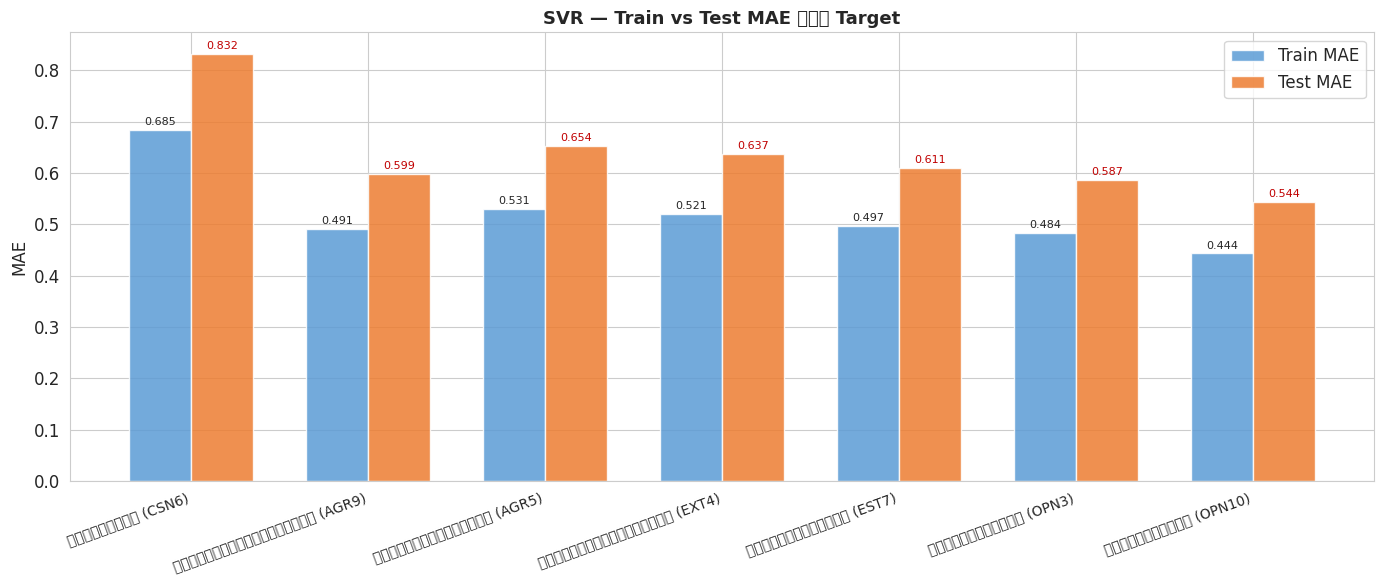

In [19]:
# 6.2 MAE Comparison Chart (Train vs Test)
x_labels = [TARGET_LABELS[c] for c in TARGET_COLS]
mae_train_vals = [svm_results[c]['MAE_train'] for c in TARGET_COLS]
mae_test_vals  = [svm_results[c]['MAE_test']  for c in TARGET_COLS]

x = np.arange(len(TARGET_COLS))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
b1 = ax.bar(x - width/2, mae_train_vals, width, label='Train MAE', color='#5B9BD5', alpha=0.85)
b2 = ax.bar(x + width/2, mae_test_vals,  width, label='Test MAE',  color='#ED7D31', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=20, ha='right', fontsize=10)
ax.set_ylabel('MAE')
ax.set_title('SVR — Train vs Test MAE ต่อ Target', fontsize=13, fontweight='bold')
ax.legend()

for bar in b1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in b2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8, color='#C00000')

plt.tight_layout()
plt.show()

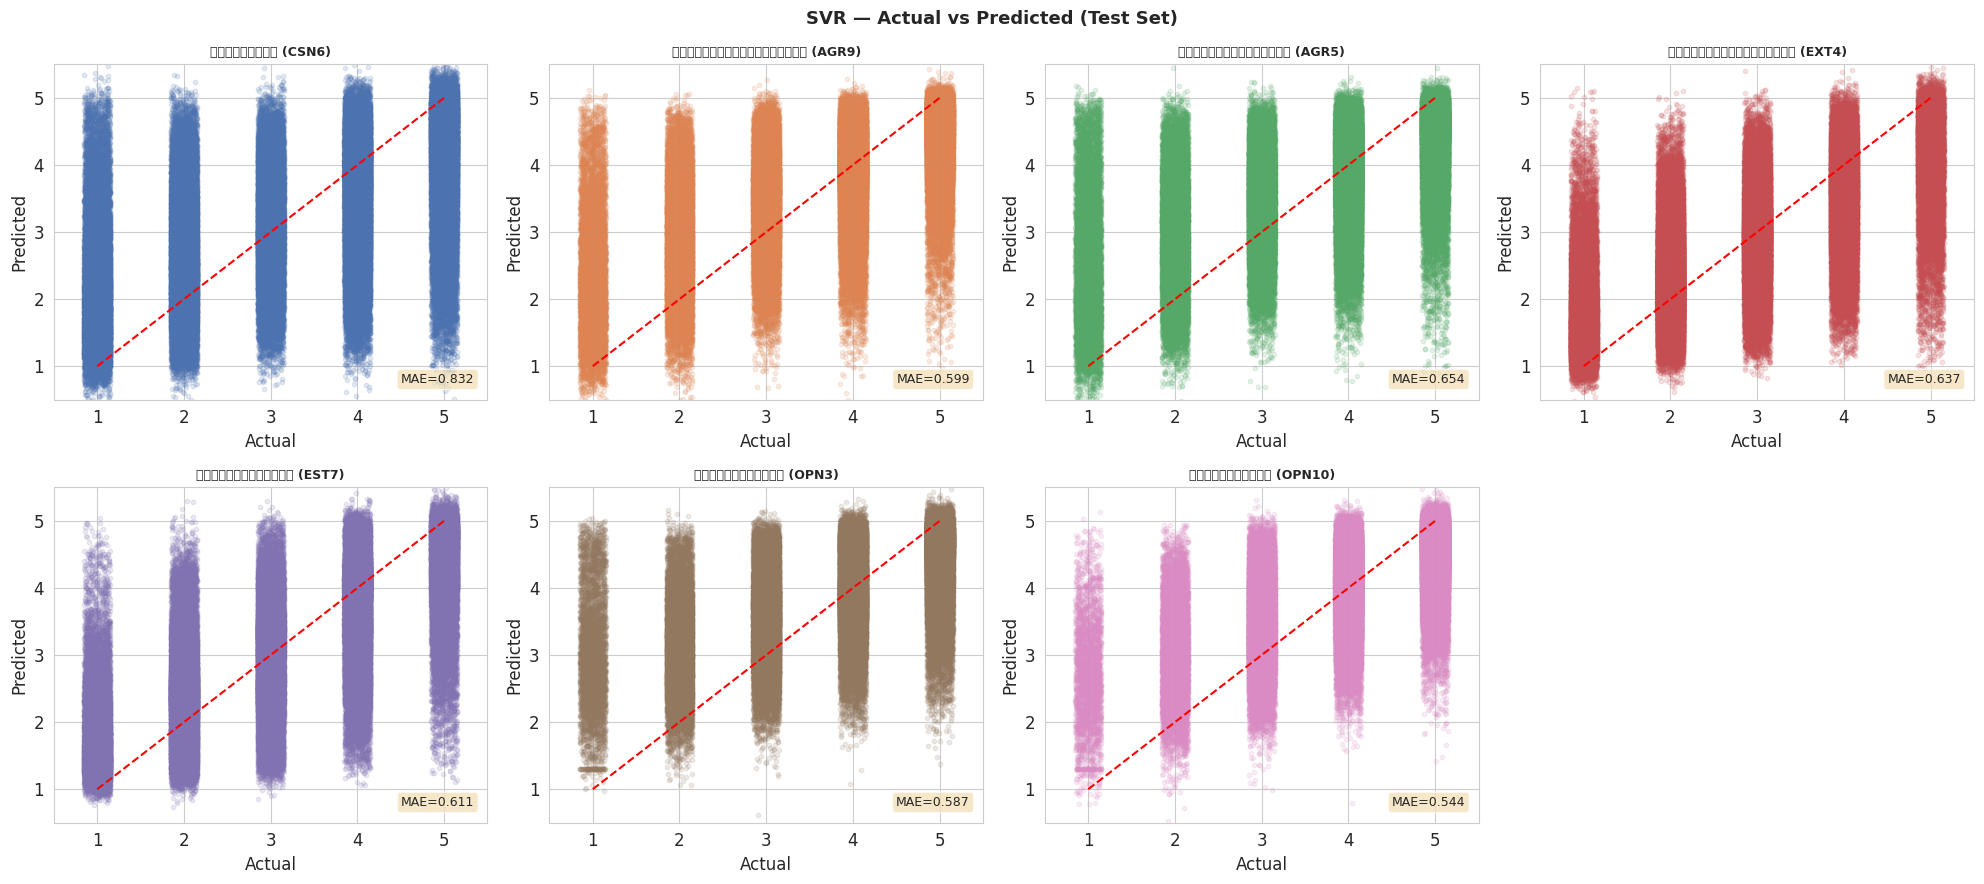

In [20]:
# 6.3 Actual vs Predicted
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for i, target in enumerate(TARGET_COLS):
    ax = axes[i]
    actual    = y_test[target].values
    predicted = svm_results[target]['y_pred_test']
    jitter    = np.random.uniform(-0.15, 0.15, size=len(actual))

    ax.scatter(actual + jitter, predicted, alpha=0.15, s=10, color=colors[i])
    ax.plot([1, 5], [1, 5], 'r--', linewidth=1.5)
    ax.set_xlim(0.5, 5.5); ax.set_ylim(0.5, 5.5)
    ax.set_title(TARGET_LABELS[target], fontsize=9, fontweight='bold')
    ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
    ax.text(0.97, 0.05, f'MAE={svm_results[target]["MAE_test"]:.3f}',
            transform=ax.transAxes, ha='right', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

axes[-1].set_visible(False)
fig.suptitle('SVR — Actual vs Predicted (Test Set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

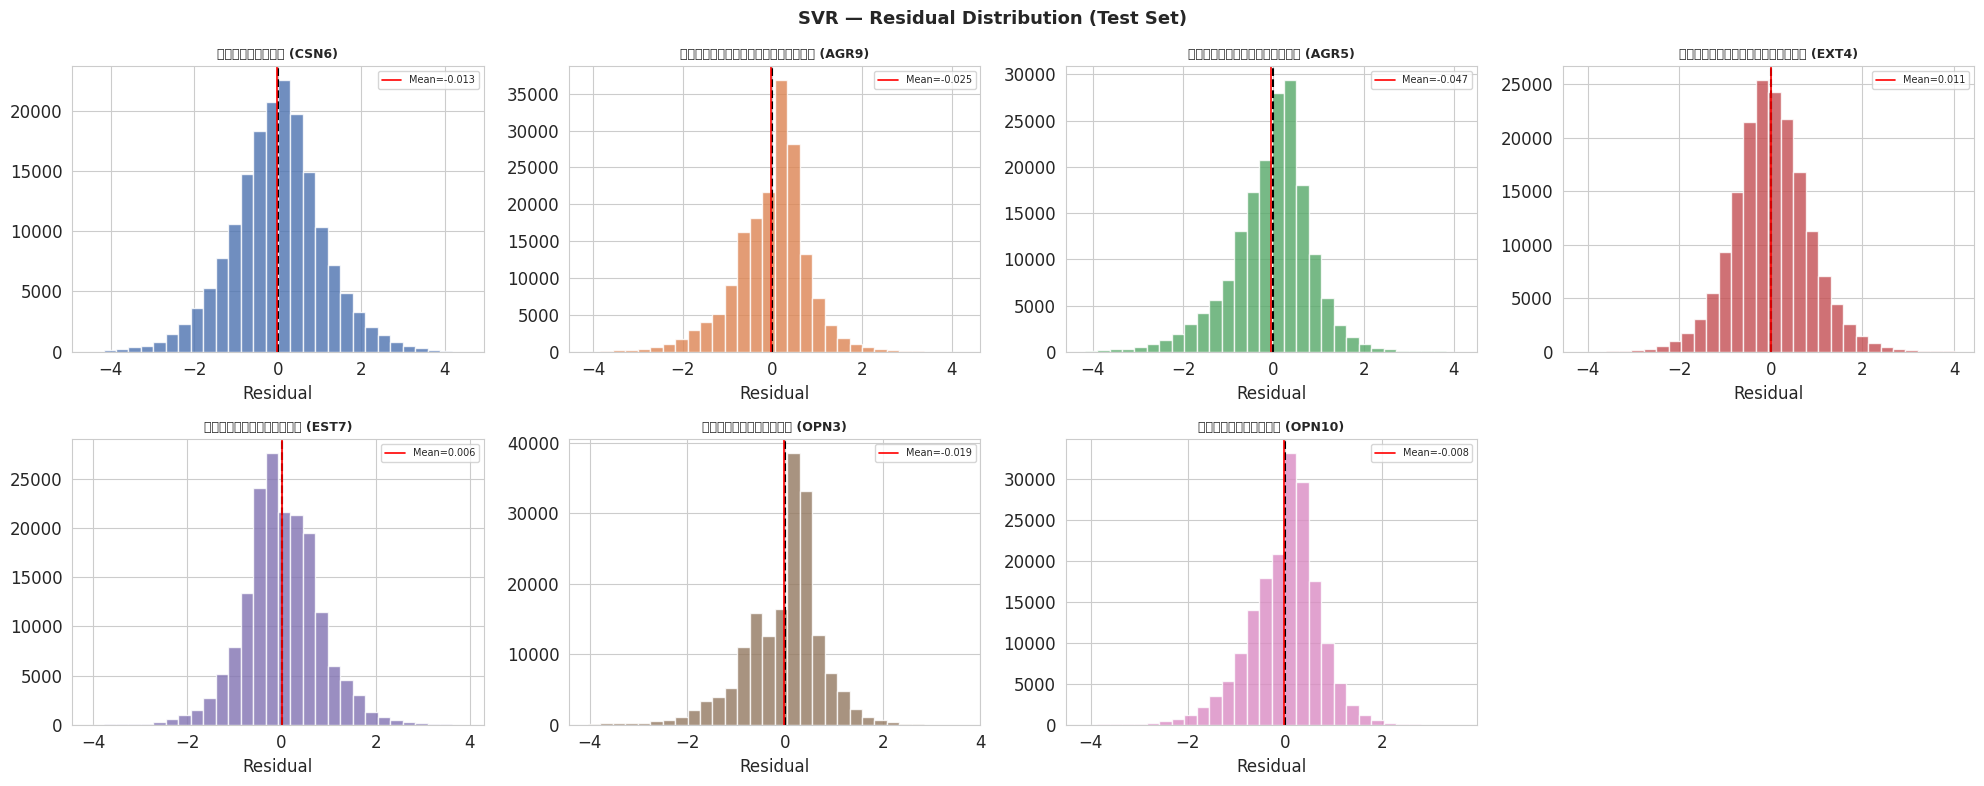

In [21]:
# 6.4 Residual Distribution
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for i, target in enumerate(TARGET_COLS):
    ax = axes[i]
    residuals = y_test[target].values - svm_results[target]['y_pred_test']
    ax.hist(residuals, bins=30, color=colors[i], alpha=0.8, edgecolor='white')
    ax.axvline(0, color='black', linestyle='--', linewidth=1.5)
    ax.axvline(residuals.mean(), color='red', linestyle='-', linewidth=1.2,
               label=f'Mean={residuals.mean():.3f}')
    ax.set_title(TARGET_LABELS[target], fontsize=9, fontweight='bold')
    ax.set_xlabel('Residual')
    ax.legend(fontsize=7)

axes[-1].set_visible(False)
fig.suptitle('SVR — Residual Distribution (Test Set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# 7 — Save Models

In [22]:
os.makedirs('models_svm', exist_ok=True)

# บันทึก scaler ด้วย — จำเป็นมากเพราะต้อง transform input ก่อน predict เสมอ
joblib.dump(scaler, 'models_svm/svm_scaler.pkl')

for target, model in svm_models.items():
    joblib.dump(model, f'models_svm/svm_{target}.pkl')

print('Saved scaler + all SVR models to models_svm/')

Saved scaler + all SVR models to models_svm/


# 8 — Final Summary

In [23]:
print('=' * 65)
print('           FINAL MODEL SUMMARY — SVR (RBF Kernel)')
print('=' * 65)
print(f'  Total samples (after clean) : {len(X):,}')
print(f'  Training samples (sampled)  : {SAMPLE_SIZE:,}')
print(f'  Train / Test split          : 80% / 20%')
print(f'  Features                    : {len(FEATURE_COLS)} columns')
print(f'  Kernel                      : RBF  |  C=1.0  |  ε=0.3')
print('-' * 65)
print(f'  {"Target":<30} {"Train MAE":>12} {"Test MAE":>12}')
print('-' * 65)
for col in TARGET_COLS:
    r = svm_results[col]
    print(f'  {TARGET_LABELS[col]:<30} {r["MAE_train"]:>12.4f} {r["MAE_test"]:>12.4f}')
print('-' * 65)
avg_test  = np.mean([svm_results[c]['MAE_test']  for c in TARGET_COLS])
avg_train = np.mean([svm_results[c]['MAE_train'] for c in TARGET_COLS])
print(f'  {"AVERAGE":<30} {avg_train:>12.4f} {avg_test:>12.4f}')
print('=' * 65)
print(f'\n  Scale: 1–5 → MAE < 0.5 ถือว่าอยู่ในเกณฑ์ดี')

           FINAL MODEL SUMMARY — SVR (RBF Kernel)
  Total samples (after clean) : 874,434
  Training samples (sampled)  : 50,000
  Train / Test split          : 80% / 20%
  Features                    : 43 columns
  Kernel                      : RBF  |  C=1.0  |  ε=0.3
-----------------------------------------------------------------
  Target                            Train MAE     Test MAE
-----------------------------------------------------------------
  ลืมวางของ (CSN6)                     0.6845       0.8325
  รู้สึกอารมณ์คนอื่น (AGR9)            0.4912       0.5988
  สนใจปัญหาคนอื่น (AGR5)               0.5308       0.6536
  ชอบอยู่ในพื้นหลัง (EXT4)             0.5209       0.6374
  อารมณ์แปรปรวน (EST7)                 0.4970       0.6108
  จินตนาการสูง (OPN3)                  0.4835       0.5869
  มีไอเดียมาก (OPN10)                  0.4440       0.5441
-----------------------------------------------------------------
  AVERAGE                              0.5217       0.6377

